### Imports

In [1]:
from datasets import load_dataset
from pprint import pprint
import pandas as pd
import random

import seaborn as sns
from matplotlib import pyplot as plt

### Load dataset

In [2]:
meta_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_All_Beauty", trust_remote_code=True)

In [3]:
pprint(meta_dataset["full"][0])

{'author': None,
 'average_rating': 4.8,
 'bought_together': None,
 'categories': [],
 'description': [],
 'details': '{"Package Dimensions": "7.1 x 5.5 x 3 inches; 2.38 Pounds", '
            '"UPC": "617390882781"}',
 'features': [],
 'images': {'hi_res': [None,
                       'https://m.media-amazon.com/images/I/71i77AuI9xL._SL1500_.jpg'],
            'large': ['https://m.media-amazon.com/images/I/41qfjSfqNyL.jpg',
                      'https://m.media-amazon.com/images/I/41w2yznfuZL.jpg'],
            'thumb': ['https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg',
                      'https://m.media-amazon.com/images/I/41w2yznfuZL._SS40_.jpg'],
            'variant': ['MAIN', 'PT01']},
 'main_category': 'All Beauty',
 'parent_asin': 'B01CUPMQZE',
 'price': 'None',
 'rating_number': 10,
 'store': 'Howard Products',
 'subtitle': None,
 'title': 'Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)',
 'videos': {'title': [], 'url': [], 'user_id': []}}


### Convert to dataframe

In [10]:
meta_df = meta_dataset["full"].to_pandas()

In [11]:
meta_df.shape, meta_df['parent_asin'].nunique()

((112590, 16), 112590)

In [12]:
meta_df.drop(columns=['images', 'videos'], inplace=True)

### Explore columns

| Field           | Type   | Explanation                                                        |
|-----------------|--------|--------------------------------------------------------------------|
| main_category   | str    | Main category (i.e., domain) of the product.                       |
| title           | str    | Name of the product.                                               |
| average_rating  | float  | Rating of the product shown on the product page.                   |
| rating_number   | int    | Number of ratings in the product.                                  |
| features        | list   | Bullet-point format features of the product.                       |
| description     | list   | Description of the product.                                        |
| price           | float  | Price in US dollars (at time of crawling).                         |
| images          | list   | Images of the product. Each has sizes (thumb, large, hi_res). The “variant” field shows image position. |
| videos          | list   | Videos of the product including title and url.                     |
| store           | str    | Store name of the product.                                         |
| categories      | list   | Hierarchical categories of the product.                            |
| details         | dict   | Product details, including materials, brand, sizes, etc.           |
| parent_asin     | str    | Parent ID of the product.                                          |
| bought_together | list   | Recommended bundles from the websites.                             |


In [7]:
meta_df.columns

Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'store', 'categories', 'details', 'parent_asin',
       'bought_together', 'subtitle', 'author'],
      dtype='object')

### Title

In [14]:
product_titles = meta_df['title'].tolist();
len(set(product_titles)) # there are some duplicates

110566

In [19]:
random.sample(product_titles, k=10)

['O Naturals Citrus & Natural Soap Collections, 2 Pack Bundle Set. 12 Unique Bars of Soap. Best Gift Set for Women & Men. Premium Skin Care Bath & Body Kit. Vegan Soap with Organic Ingredients. 4oz Each',
 'Pro 78 Color Makeup Blush & Eye shadow Powder Palette',
 "WEWBABY Gold Crown and Tiara for Women Girls Valentine's Day Baroque Vintage Princess Queen Crown Birthday Tiara Headbands for Wedding Prom Bridal Party with 2 Hair Clips",
 'Avon Skin So Soft Original Gelled Body Oil',
 'Facial Hair Remover for Women, ZACCER Painless Hair Removal Waterproof Shaver Razor with LED Light for Peach Fuzz Fine Hair Chin Cheek Upper Lip',
 'Face Make Up Primer & Liquid Foundation Double Tube Long-Lasting Oil Control Soft Moist Hide Pores Isolation Improving Skin Beauty',
 'Kamasutra Body Paint - Milk Chocolate 2 fl oz 59ml',
 '36 Pieces Halloween Costume Contest Award Prize Ribbons for Halloween Party Awards',
 'Bronze Cactus Glow, Double Dipped Ultra Dark, Anti-Aging, Quick Dry, 100% Vegan, Parabe

In [20]:
meta_df[['title', 'description', 'features', 'details']]

,title,description,features,details
0,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",[],[],"{""Package Dimensions"": ""7.1 x 5.5 x 3 inches; ..."
1,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,[],[],"{""Item Form"": ""Powder"", ""Skin Type"": ""Acne Pro..."
2,Eye Patch Black Adult with Tie Band (6 Per Pack),[],[],"{""Manufacturer"": ""Levine Health Products""}"
3,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",[],[],"{""Brand"": ""Cherioll"", ""Item Form"": ""Powder"", ""..."
4,Precision Plunger Bars for Cartridge Grips – 9...,[The Precision Plunger Bars are designed to wo...,"[Material: 304 Stainless Steel; Brass tip, Len...","{""UPC"": ""644287689178""}"
...,...,...,...,...
112585,"TOPREETY 24""120gr 3/4 Full Head clip in hair e...",[],[],"{""Is Discontinued By Manufacturer"": ""No"", ""Pac..."
112586,"Pets Playmate Pet Grooming Glove,Gentle Deshed...",[],[],"{""Is Discontinued By Manufacturer"": ""No"", ""Pac..."
112587,[10Pack] Makeup Brushes Set Cosmetics Tools Ki...,[],[],"{""Brand"": ""RainMakers"", ""Recommended Uses For ..."
112588,Xcoser Pretty Party Anna Wig Hair Tails Hair S...,[],[],"{""Is Discontinued By Manufacturer"": ""No"", ""Pac..."


### Average rating

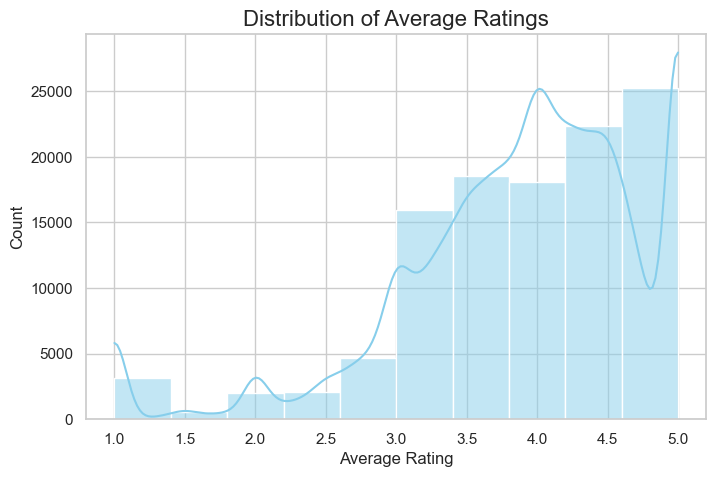

In [18]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
sns.histplot(meta_df["average_rating"], bins=10, kde=True, color="skyblue")

plt.title("Distribution of Average Ratings", fontsize=16)
plt.xlabel("Average Rating")
plt.ylabel("Count")
plt.show()

In [40]:
meta_df['rating_number'].describe()

count    112590.000000
mean         50.541345
std         310.992502
min           1.000000
25%           3.000000
50%           9.000000
75%          28.000000
max       30206.000000
Name: rating_number, dtype: float64

### Features

In [21]:
import numpy as np

In [25]:
random.choices(meta_df['description'], k = 10)

[array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array(['2 PACKS - SHINE -DEFINE PROTEIN RICH -SLAY YOUR EDGES WITH NO COMMENTS -NO WAX, NO GREASE, NO ALCOHOL, NO FLAKING'],
       dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array(['Rapid Developing & Color Prolonging Formula With Strictly BlackTM you have hit the bronzing jackpot! This insanely dark bronzer is formulated with melanin stimulators to produce and prolong deep, dark bronzing results. Added Advanced Matrixyl Synthe 6TM and RevitaFitTM benefits make this product your go to lotion for fast visible bronzing and tightening results... Instantly! Dare to ask yourself, how dark will you go?'],
       dtype=object),
 array(['Slather this rich, nourishing lotion on your entire body to leave skin feeling deeply moisturized and energized. Infused with botanicals and skin essential vitamins, Maximum Hydration Body Lotion helps nou

In [30]:
random.choices(meta_df['details'], k = 10)

['{"Age Range (Description)": "Adult", "Material": "Cotton", "Fabric Type": "Cotton", "Number of Items": "1", "Brand": "Keshet Accessories", "Item model number": "kshw-paisley-bandana-blue"}',
 '{"Is Discontinued By Manufacturer": "No", "Package Dimensions": "2.5 x 2 x 0.1 inches; 0.63 Ounces", "UPC": "644747392792"}',
 '{"Shape": "Flat", "Brand": "EV Beauty", "Hair Type": "Straight", "Power Source": "Corded Electric", "Package Dimensions": "9.4 x 4.9 x 0.4 inches; 0.35 Ounces"}',
 '{"Brand": "Grace Cole", "Item Form": "Liquid", "Unit Count": "10.00 Fl Oz", "Number of Items": "1", "Use for": "Hands", "Is Discontinued By Manufacturer": "No", "Product Dimensions": "2.2 x 2.2 x 7.28 inches; 11.36 Ounces", "Manufacturer": "Grace Cole"}',
 '{"Is Discontinued By Manufacturer": "No", "Package Dimensions": "9.7 x 5.8 x 0.9 inches; 2.4 Ounces", "UPC": "702563114643", "Manufacturer": "Leshery"}',
 '{"Brand": "BASHO FAN", "Color": "BLACK", "Shape": "Oval", "Bristle Material": "Wood", "Handle Mate

In [31]:
non_empty_features = meta_df[meta_df['features'].apply(lambda x: isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0)]

In [32]:
non_empty_features.reset_index(drop=True, inplace=True)

In [40]:
random.choices(non_empty_features['features'], k = 3)

[array(['COCONUT MILK MELT & POUR GLYCERIN SOAP BASE: 100% Natural. Premium Quality. Non-GMO. Cruelty Free. Soy free. SLS/SLES Free.',
        'Our high quality Melt and Pour Soap Base was specially created with high glycerin content and only natural ingredients, that makes soap making process easy and enjoyable. Simply melt it, pour it, customize it with your favorite colors and scents and allow it to cool. It is perfect for beginners and those who have been doing this for years.',
        'CLEANSE AND MOISTURIZE THE SKIN: Coconut milk packed with a lot of fatty acids, that can deeply cleanse the skin be removing all the dirt, dust and dead cells. It believed to provide hydration, moisture, eliminate blemishes. Vitamin C and E in coconut oil can help promote cells regeneration, increase elasticity of the skin, minimize fine lines and wrinkles.',
        'PERFECT CUSTOM GIFT: Let’s face it, who doesn’t like receiving something that is natural, handmade, and luxurious! It’s easy to make

### Description

In [34]:
# description also has some empty values
random.choices(meta_df['description'], k = 10)

[array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array(['Package\xa0Include: 12\xa0x\xa0Foils\xa0Flakes 12\xa0x\xa0Holographic\xa0Chunky\xa0Glitter 12\xa0x\xa0Mermaid\xa0Nail\xa0Sequins 16\xa0x\xa0Nail\xa0Foil\xa0Transfer\xa0Sticker 1\xa0x\xa03D\xa0Metal\xa0Nail\xa0Studs 1\xa0x\xa0Nails\xa0Rhinestones\xa0with\xa01\xa0Pen How to use: (Except transfer stickers) 1.Apply primer and cure by UV/Led lamp for 1 mins. 2.Apply color polish.(Don’t cure!) 3.Use tweezer to put the accessories onto your nails. 4.cure by UV/Led lamp for 1 mins. 5.Apply the top glue, cure by UV/Led lamp for 1 mins. How to use the transfer stickers: 1.Apply primer and cure for 1 mins. 2.Apply nail foil transfer glue, cure by UV/Led lamp for 1 mins. 3.Put the nail art foil transfer sticker on the nails, press the surface of the nails. 4.Apply the top glue, cure by UV/Led lamp for 1 mins.'

In [35]:
non_empty_description = meta_df[meta_df['description'].apply(lambda x: isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0)]

In [36]:
non_empty_description.reset_index(drop=True, inplace=True)

In [39]:
random.choices(non_empty_description['description'], k = 3)

[array(['Features:',
        '1.It is made of high quality materials, durable enough for your daily wearing2.Stylish and fashion design make you more attractive3.Comfortable material, suitable for home occasions.4.Serve as a nightwear and also a stimulative sex kit for sexual life of couples.'],
       dtype=object),
 array(["Bring your Girls Only party to full swing when you add these QTni bachelorette vibrant temporary metallic flash tattoos! Create limitless number of ways to add fun and colors to your party attendees. The set comes with 69 tattoos printed durable foil non-toxic waterproof material. Go wild with your last Fling Before the Ring with fun and creative body / hair decoration. Buy Now and you're set for the most memorable night of your life."],
       dtype=object),
 array(['This contemporary masculine fragrance invokes history with classic citrus top notes and a deep, mossy complexion. Subtle bursts of fragrant rose, spicy cinnamon and fresh cedarwood enrich the blend, 

### Content

In [62]:
# Simple data quality check for core columns
print("Core columns for retrieval comparison:")
print(f"Titles: {meta_df['title'].notna().sum()}/{len(meta_df)} ({(meta_df['title'].notna().sum()/len(meta_df)*100):.1f}%)")

# Check how many products have ANY descriptive content
has_features = meta_df['features'].apply(lambda x: isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0)
has_description = meta_df['description'].apply(lambda x: isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0)
has_content = has_features | has_description

print(f"Products with features: {has_features.sum()}")
print(f"Products with descriptions: {has_description.sum()}")
print(f"Products with ANY content (features OR description): {has_content.sum()}")
print(f"Content coverage: {(has_content.sum()/len(meta_df)*100):.1f}%")

Core columns for retrieval comparison:
Titles: 112590/112590 (100.0%)
Products with features: 17377
Products with descriptions: 19162
Products with ANY content (features OR description): 23844
Content coverage: 21.2%


### Details

In [44]:
random.choices(meta_df['details'], k = 10)

['{"Item Form": "Oil", "Unit Count": "8.0 Fl Oz", "Number of Items": "1", "Item Weight": "2.61 Ounces", "Package Type": "Bottle", "Is Discontinued By Manufacturer": "No", "UPC": "077349611723"}',
 '{"Package Dimensions": "8.15 x 4.17 x 2.28 inches; 3 Ounces", "UPC": "743829389467"}',
 '{"Color": "White", "Material": "Wood", "Hair Type": "Straight", "Brand": "WILLBOND", "Age Range (Description)": "Adult", "Package Dimensions": "6.06 x 5.71 x 2.17 inches; 7.97 Ounces"}',
 '{"Brand": "ZARICS", "Item Form": "Powder", "Finish Type": "Glitter,Matte,Shimmer", "Special Feature": "Waterproof, Matte, Long lasting", "Product Benefits": "Smoothening", "Package Dimensions": "3.86 x 3.74 x 0.55 inches; 2.4 Ounces"}',
 '{"Product Dimensions": "2.32 x 1.97 x 5.04 inches; 0.71 Ounces", "Item model number": "Unibellqwgnkh1fau-01", "Manufacturer": "Unibell"}',
 '{"Brand": "MEACOLIA", "Material": "Plastic", "Capacity": "8 Ounces", "Package Dimensions": "10 x 9.13 x 4.25 inches; 9.59 Ounces", "UPC": "19349

### Price

In [45]:
# price also has some empty values
random.choices(meta_df['price'], k = 10)

['None',
 'None',
 'None',
 'None',
 '42.99',
 'None',
 'None',
 'None',
 'None',
 '9.99']

### Categories

In [50]:
random.choices(meta_df['categories'], k = 10)

[array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object),
 array([], dtype=object)]

In [51]:
non_empty_categories = meta_df[meta_df['categories'].apply(lambda x: isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0)]

In [52]:
non_empty_categories.reset_index(drop=True, inplace=True)

In [54]:
non_empty_categories.shape

(0, 14)

### Store

In [55]:
random.choices(meta_df['store'], k = 10)

['Icarus',
 'MESHA',
 None,
 'Metamuclia',
 'Hairro',
 'Botanical Garden',
 'ALIANNA',
 'Potentcera',
 'LongXTX',
 'Boao']

In [61]:
vc = dict(meta_df['store'].value_counts())
top10 = dict(list(vc.items())[:10])
top10

{'Bath & Body Works': 481,
 'WILLBOND': 388,
 'Hairro': 381,
 'Generic': 369,
 'S-noilite': 340,
 'AVON': 283,
 'Maitys': 244,
 'Sunny Hair': 242,
 'Boao': 208,
 'Patelai': 204}

### Columns to keep

To keep it simple I will just begin with title, features and description columns

### Saving the data

In [63]:
def has_content(row):
  has_features = isinstance(row['features'], (list, tuple, np.ndarray)) and len(row['features']) > 0
  has_description = isinstance(row['description'], (list, tuple, np.ndarray)) and len(row['description']) > 0
  has_title = pd.notna(row['title']) and len(str(row['title']).strip()) > 0
  return has_title and (has_features or has_description)

In [64]:
clean_df = meta_df[meta_df.apply(has_content, axis=1)].copy()

In [65]:
clean_df = clean_df.drop_duplicates(subset=['title']).reset_index(drop=True)

In [66]:
def combine_content(row):
  """Combine features and description into searchable text"""
  content_parts = []

  if isinstance(row['features'], (list, tuple, np.ndarray)) and len(row['features']) > 0:
      content_parts.extend(row['features'])

  if isinstance(row['description'], (list, tuple, np.ndarray)) and len(row['description']) > 0:
      content_parts.extend(row['description'])

  return " ".join(content_parts)

In [67]:
clean_df['content'] = clean_df.apply(combine_content, axis=1)

In [68]:
clean_df.head()

,main_category,title,average_rating,rating_number,features,description,price,store,categories,details,parent_asin,bought_together,subtitle,author,content
0,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,None,Precision,[],"{""UPC"": ""644287689178""}",B07NGFDN6G,None,None,None,Material: 304 Stainless Steel; Brass tip Lengt...
1,All Beauty,Lurrose 100Pcs Full Cover Fake Toenails Artifi...,3.7,35,[The false toenails are durable with perfect l...,"[Description, The false toenails are durable w...",6.99,Lurrose,[],"{""Color"": ""As Shown"", ""Size"": ""Large"", ""Materi...",B07G9GWFSM,None,None,None,The false toenails are durable with perfect le...
2,All Beauty,Gold extatic Musk EDT 90ml,3.7,2,[Extatic Balmain Gold Musk By Balmain Edt Spra...,[Edt spray 3 oz design house: balmain],86.95,Balmain,[],"{""Brand"": ""Balmain"", ""Item Form"": ""Spray"", ""It...",B01ERJEGS6,None,None,None,Extatic Balmain Gold Musk By Balmain Edt Spray...
3,All Beauty,Small MONEY CLIP Leather Wallet ID Bag Cash Ho...,3.0,6,"[Package:OPP, Step 1 : Open Clip and Put Money...",[Description Small MONEY CLIP Leather Wallet I...,None,Buytra,[],"{""Department"": ""Mens"", ""UPC"": ""520661393605 70...",B00FCQHYEW,None,None,None,Package:OPP Step 1 : Open Clip and Put Money I...
4,All Beauty,Nomade By Chloe,4.2,8,[],[new],None,Chloe,[],"{""Brand"": ""Chloe"", ""Item Volume"": ""100 Millili...",B07ZJW55Z5,None,None,None,new


In [69]:
final_df = clean_df[['parent_asin', 'title', 'content', 'store', 'price', 'average_rating']].copy()

In [70]:
if len(final_df) >= 1000:
  final_sample = final_df.sample(n=1000, random_state=42).reset_index(drop=True)
else:
  final_sample = final_df.copy()
  print(f"Warning: Only {len(final_df)} products available, using all of them")

In [71]:
final_sample.shape

(1000, 6)

In [72]:
final_sample.to_csv('amazon_beauty_products_1000.csv', index=False)

print(f"Final dataset: {len(final_sample)} products")
print(f"Columns: {list(final_sample.columns)}")
print("\nSample product:")
print(f"Title: {final_sample.iloc[0]['title']}")
print(f"Content preview: {final_sample.iloc[0]['content'][:200]}...")

Final dataset: 1000 products
Columns: ['parent_asin', 'title', 'content', 'store', 'price', 'average_rating']

Sample product:
Title: Careline Super Long Lasting Automatic Eye Pencil (204 Shiny Blue)
Content preview: eye automatic pencil...


In [73]:
final_sample.head()

,parent_asin,title,content,store,price,average_rating
0,B01LZG89RR,Careline Super Long Lasting Automatic Eye Penc...,eye automatic pencil,Careline,None,4.7
1,B09LLV9TPV,Dailinna Corn Wave Ponytail Extension Clip in ...,Style: Drawstring corn wave ponytail hair exte...,Dailinna,None,3.0
2,B07J4VNYW1,"ZUM Holiday Mint Blitzum Mist, 4 FZ",Spray a little merry wherever and whenever a m...,Indigo Wild,None,4.5
3,B08KFFB2PP,Perfectly Posh PLAY DATE Super Moisturizing Nu...,Super Moisturizing Nutrient-Rich Coconut Oil i...,Perfectly Posh,None,3.9
4,B09MQ53X93,New for 2021 Bath and Body Works Gingham Heart...,All items come from a smoke and pet free envir...,Bath & Body Works,38.9,4.7
